## Augabe 5 - Ahmed Adnan, Eugen Erb, Nicolas Huhle

### Hough-Transformation

#### read the image using OpenCV (cv2) and display it with matplotlib. 

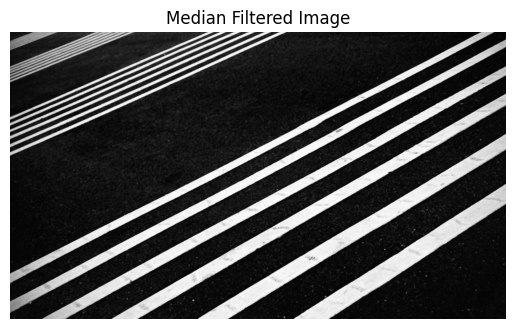

In [183]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# Load image (grayscale)
#image = cv2.imread('noisy-lines.tif', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('street.png', cv2.IMREAD_GRAYSCALE)

# Apply median filter to reduce noise
denoised = cv2.medianBlur(image, ksize=3)

plt.imshow(denoised, cmap='gray')
plt.title("Median Filtered Image")
plt.axis('off')
plt.show()


#### Apply Canny edge detection
We apply the Canny edge detector, which uses gradients and hysteresis thresholding. You can tune the threshold1 and threshold2 values as needed. <br> <br>
threshold1: Lower bound – controls sensitivity (lower = more edges, more noise).

threshold2: Upper bound – controls strictness (higher = fewer, stronger edges).

#### Binarize edge image (set edges to 1, rest to 0)
We convert the result to binary: all non-zero values become 1, others stay 0

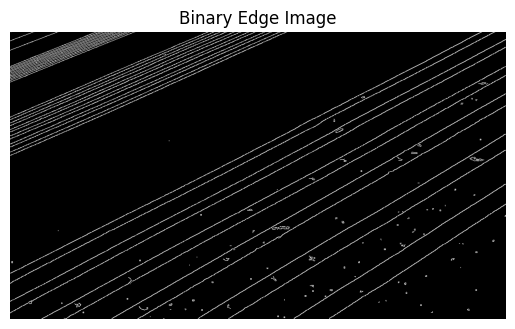

In [184]:
# Canny edge detection
edges = cv2.Canny(denoised, threshold1=70, threshold2=200)

# Binarize edge image
binary_edges = (edges > 0).astype(np.uint8)

plt.imshow(binary_edges, cmap='gray')
plt.title("Binary Edge Image")
plt.axis('off')
plt.show()


#### Implement the Hough Line Transform using the Hesse normal form <br>

ρ=x⋅cos(θ)+y⋅sin(θ)
We loop over each edge pixel (x,y),<br> calculate ρ for a set of angles θ,<br> and vote in an accumulator array (a 2D histogram of 
(ρ,θ)).

In [165]:
def linearHT(im_edge, angle_steps, radius_steps):
    height, width = im_edge.shape
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))
    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)
    accumulator = np.zeros((radius_steps, angle_steps), dtype=np.int32)

    y_idxs, x_idxs = np.nonzero(im_edge)
    for x, y in zip(x_idxs, y_idxs):
        for t_idx, theta in enumerate(thetas):
            rho = x * np.cos(theta) + y * np.sin(theta)
            r_idx = int(np.round((rho + max_dist) * (radius_steps - 1) / (2 * max_dist)))
            if 0 <= r_idx < radius_steps:
                accumulator[r_idx, t_idx] += 1

    return accumulator


#### Display the accumulator array to see the Hough space.
Peaks in this space indicate likely lines in the original image.

In [166]:
def plot_hough_accumulator(accumulator, angle_steps, radius_steps):
    plt.figure(figsize=(10, 8))
    plt.imshow(accumulator, cmap='hot', aspect='auto')
    plt.title("Hough Accumulator")
    plt.xlabel("Angle (θ)")
    plt.ylabel("Radius (ρ)")
    plt.colorbar(label='Votes')
    plt.xticks(
        ticks=np.linspace(0, angle_steps - 1, 5),
        labels=[f"{round(x, 2)}" for x in np.linspace(-90, 90, 5)]
    )
    plt.yticks(
        ticks=np.linspace(0, radius_steps - 1, 5),
        labels=[f"{round(x, 0)}" for x in np.linspace(-accumulator.shape[0]//2, accumulator.shape[0]//2, 5)]
    )
    plt.tight_layout()
    plt.show()


#### Identify the peaks in the Hough accumulator that likely correspond to real lines in the image.

In [167]:
def find_hough_peaks(accumulator, threshold_ratio=0.5):
    """
    Finds peaks in the Hough accumulator based on a threshold.

    Parameters:
    accumulator (2D np.array): The Hough accumulator.
    threshold_ratio (float): Percentage of max votes to use as threshold (e.g., 0.5 = 50%)

    Returns:
    List of (rho_idx, theta_idx) tuples where the vote count exceeds the threshold.
    """
    threshold = threshold_ratio * np.max(accumulator)
    peaks = np.argwhere(accumulator >= threshold)
    return [tuple(p) for p in peaks]

In [168]:
def non_max_suppression(accumulator, threshold_ratio=0.6, neighborhood_size=7):
    threshold = threshold_ratio * np.max(accumulator)
    local_max = maximum_filter(accumulator, size=neighborhood_size) == accumulator
    above_thresh = accumulator >= threshold
    detected_peaks = np.argwhere(local_max & above_thresh)
    return [tuple(p) for p in detected_peaks]


In [169]:
def draw_detected_lines(image, peaks, angle_steps, radius_steps):
    height, width = image.shape[:2]
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))
    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)
    img_with_lines = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    for r_idx, t_idx in peaks:
        rho = rhos[r_idx]
        theta = thetas[t_idx]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 1)

    return img_with_lines


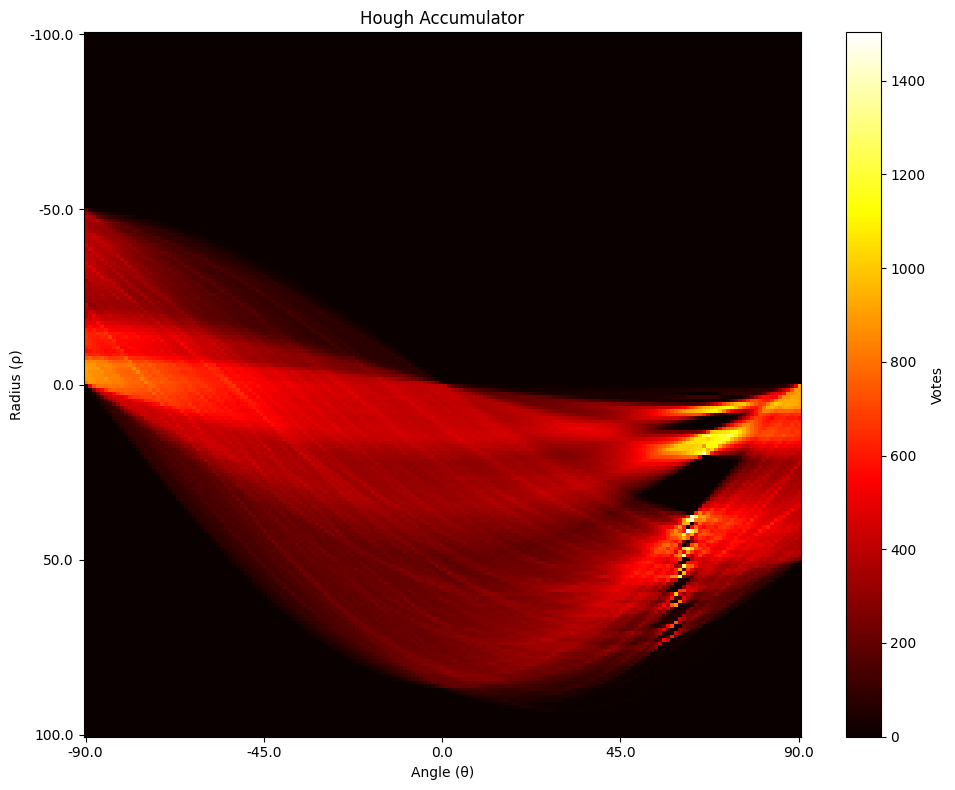

In [170]:
# Set parameters
angle_steps = 180
radius_steps = 200

# Run Hough Transform
accumulator = linearHT(binary_edges, angle_steps, radius_steps)
plot_hough_accumulator(accumulator, angle_steps, radius_steps)


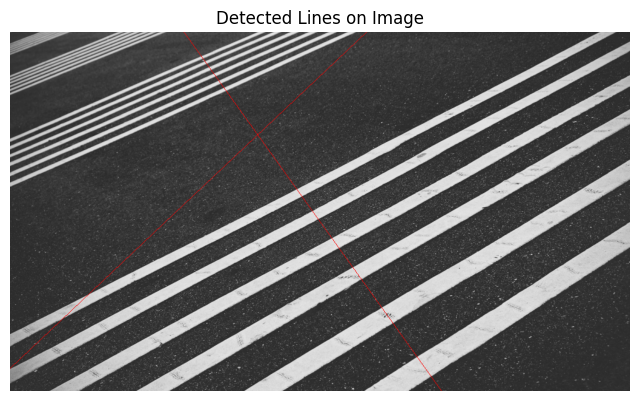

In [189]:
# Recreate grayscale if needed
gray_for_lines = image2 if len(image2.shape) == 2 else cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Get peaks
peaks = non_max_suppression(accumulator, threshold_ratio=0.7, neighborhood_size=5)

# Draw lines
img_with_lines = draw_detected_lines(gray_for_lines, peaks, angle_steps, radius_steps)

# Show result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_with_lines, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines on Image")
plt.axis('off')
plt.show()


In [172]:
# Sobel gradient magnitude
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
gradient_magnitude = (gradient_magnitude / gradient_magnitude.max() * 255).astype(np.uint8)

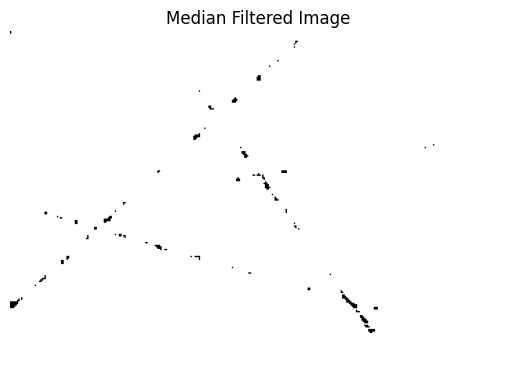

In [173]:
# Median filter for noise reduction
median_filtered = cv2.medianBlur(gray, ksize=5)

# Edge detection after denoising
edges = cv2.Canny(median_filtered, threshold1=50, threshold2=150)
binary_edges = (edges > 0).astype(np.uint8)

# Optional: show median-filtered image
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered Image")
plt.axis('off')
plt.show()


In [174]:
def linearHT(im_edge, angle_steps, radius_steps):
    height, width = im_edge.shape
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))
    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)
    accumulator = np.zeros((radius_steps, angle_steps), dtype=np.int32)

    y_idxs, x_idxs = np.nonzero(im_edge)
    for x, y in zip(x_idxs, y_idxs):
        for t_idx in range(len(thetas)):
            theta = thetas[t_idx]
            rho = x * np.cos(theta) + y * np.sin(theta)
            r_idx = int(np.round((rho + max_dist) * (radius_steps - 1) / (2 * max_dist)))
            if 0 <= r_idx < radius_steps:
                accumulator[r_idx, t_idx] += 1

    return accumulator

# Run Hough Transform
angle_steps = 180
radius_steps = 250
accumulator = linearHT(binary_edges, angle_steps, radius_steps)


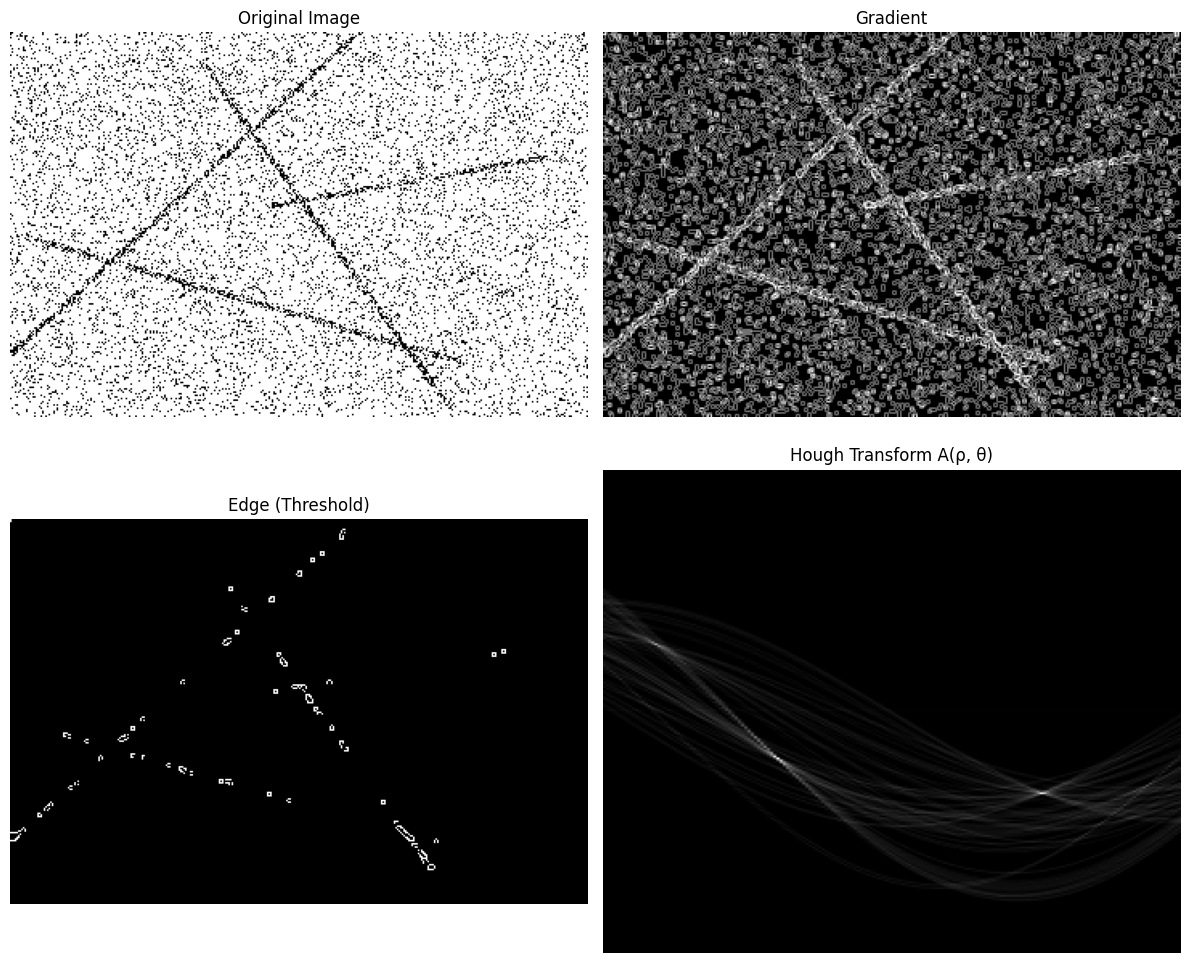

In [175]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(gray, cmap='gray')
axs[0, 0].set_title("Original Image")
axs[0, 0].axis('off')

axs[0, 1].imshow(gradient_magnitude, cmap='gray')
axs[0, 1].set_title("Gradient")
axs[0, 1].axis('off')

axs[1, 0].imshow(binary_edges, cmap='gray')
axs[1, 0].set_title("Edge (Threshold)")
axs[1, 0].axis('off')

axs[1, 1].imshow(accumulator, cmap='gray', aspect='auto')
axs[1, 1].set_title("Hough Transform A(ρ, θ)")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


In [176]:
def non_max_suppression(accumulator, threshold_ratio=0.7, neighborhood_size=9):
    threshold = threshold_ratio * np.max(accumulator)
    local_max = maximum_filter(accumulator, size=neighborhood_size) == accumulator
    above_thresh = accumulator >= threshold
    detected_peaks = np.argwhere(local_max & above_thresh)
    return [tuple(p) for p in detected_peaks]


In [177]:
def draw_detected_lines(image, peaks, angle_steps, radius_steps):
    height, width = image.shape[:2]
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))
    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)

    img_with_lines = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR) if len(image.shape) == 2 else image.copy()

    for r_idx, t_idx in peaks:
        rho = rhos[r_idx]
        theta = thetas[t_idx]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 1)

    return img_with_lines


In [185]:
# Detect peaks using NMS
peaks = non_max_suppression(accumulator, threshold_ratio=0.7, neighborhood_size=9)

# Draw detected lines
img_with_lines = draw_detected_lines(image2, peaks, angle_steps, radius_steps)


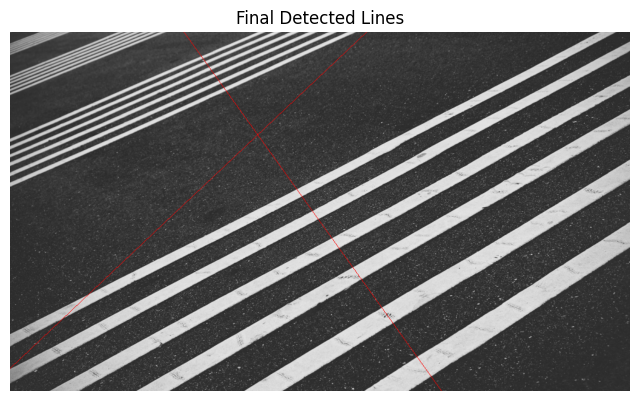

In [186]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_with_lines, cv2.COLOR_BGR2RGB))
plt.title("Final Detected Lines")
plt.axis('off')
plt.show()

# new try, cleaner

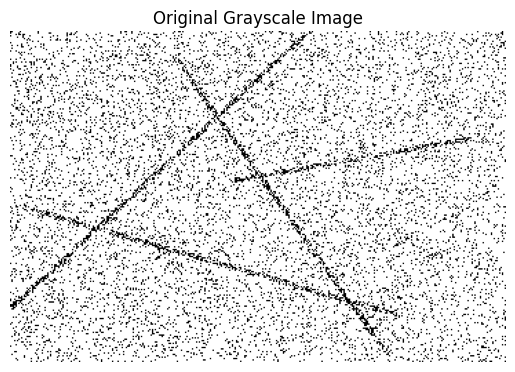

In [232]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image as grayscale directly
image = cv2.imread('noisy-lines.tif', cv2.IMREAD_GRAYSCALE)
#image = cv2.imread('street.png', cv2.IMREAD_GRAYSCALE)


plt.imshow(image, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()


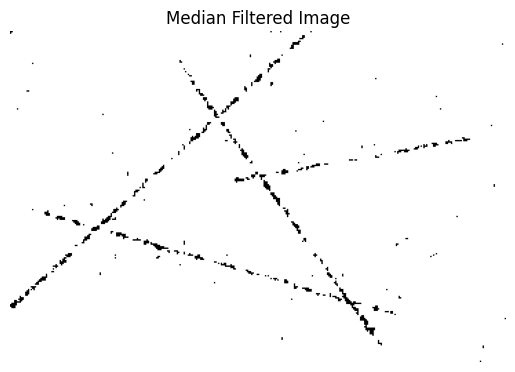

In [233]:
# Median filter to remove noise without blurring edges
median_filtered = cv2.medianBlur(image, ksize=3)

plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filtered Image")
plt.axis('off')
plt.show()


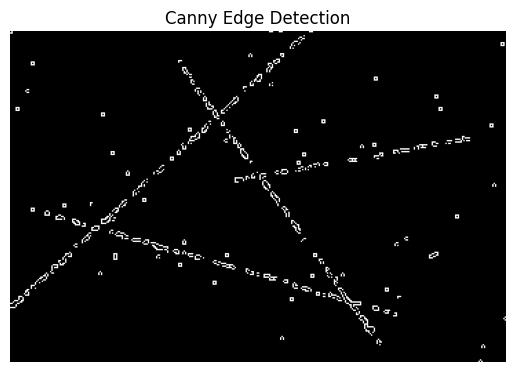

In [234]:
# Detect edges with Canny (thresholds may be tuned)
edges = cv2.Canny(median_filtered, threshold1=70, threshold2=200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()


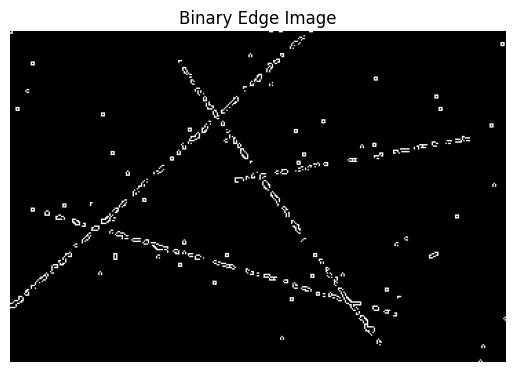

In [235]:
# Convert edge image to binary (1 = edge, 0 = non-edge)
binary_edges = (edges > 0).astype(np.uint8)

plt.imshow(binary_edges, cmap='gray')
plt.title("Binary Edge Image")
plt.axis('off')
plt.show()


In [236]:
def linearHT(im_edge, angle_steps, radius_steps):
    """
    Implements the basic Hough Line Transform using the Hesse normal form.

    Parameters:
    im_edge (2D np.array): Binary edge image (edges = 1, background = 0)
    angle_steps (int): Number of discretization steps for angle θ (theta)
    radius_steps (int): Number of discretization steps for radius ρ (rho)

    Returns:
    accumulator (2D np.array): Hough accumulator array of shape (radius_steps, angle_steps)
                               where each cell accumulates votes for a line parameterized
                               by (rho, theta).
    """
    height, width = im_edge.shape
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))  # ρ max

    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)

    accumulator = np.zeros((radius_steps, angle_steps), dtype=np.int32)

    # Get coordinates of all edge pixels
    y_idxs, x_idxs = np.nonzero(im_edge)

    # Voting in the Hough space
    for x, y in zip(x_idxs, y_idxs):
        for t_idx, theta in enumerate(thetas):
            rho = x * np.cos(theta) + y * np.sin(theta)
            r_idx = int(np.round((rho + max_dist) * (radius_steps - 1) / (2 * max_dist)))
            if 0 <= r_idx < radius_steps:
                accumulator[r_idx, t_idx] += 1

    return accumulator


In [237]:
angle_steps = 360
radius_steps = 300

accumulator = linearHT(binary_edges, angle_steps, radius_steps)


In [238]:
def plot_hough_accumulator(accumulator, angle_steps, radius_steps):
    """
    Plots the Hough accumulator as a heatmap.

    Parameters:
    accumulator (2D np.array): Output from linearHT
    angle_steps (int): Number of angle bins (theta)
    radius_steps (int): Number of radius bins (rho)
    """
    plt.figure(figsize=(10, 8))
    plt.imshow(accumulator, cmap='hot', aspect='auto')
    plt.title("Hough Accumulator A(ρ, θ)")
    plt.xlabel("Angle θ index")
    plt.ylabel("Radius ρ index")
    plt.colorbar(label='Votes')
    plt.tight_layout()
    plt.show()


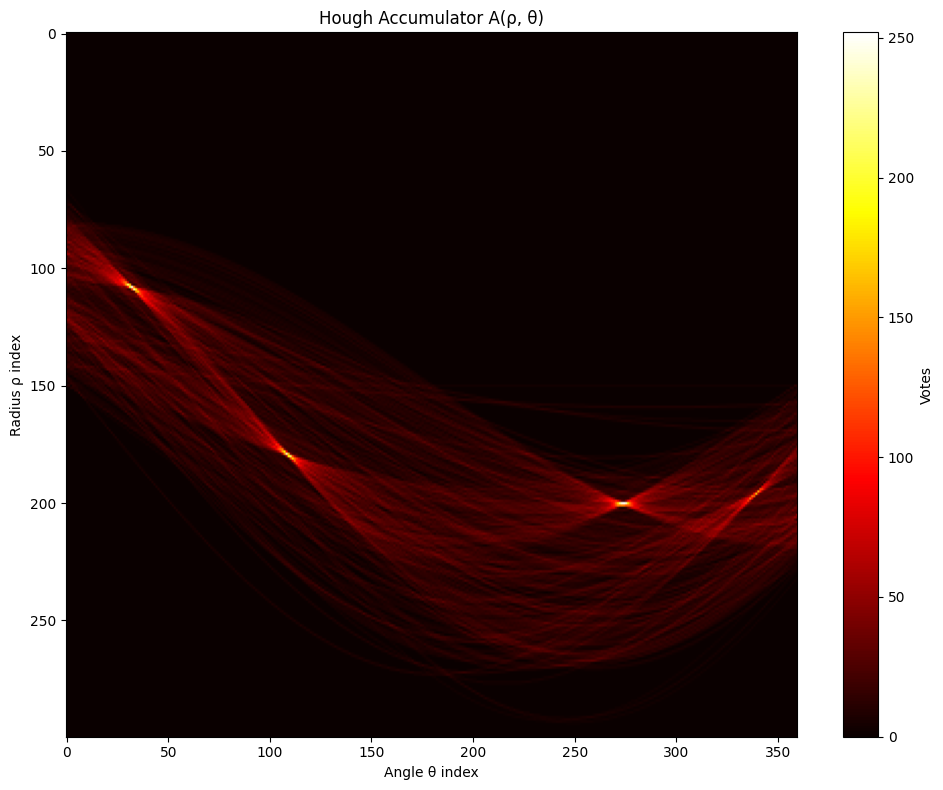

In [239]:
plot_hough_accumulator(accumulator, angle_steps, radius_steps)


In [240]:
from scipy.ndimage import maximum_filter

def non_max_suppression(accumulator, threshold_ratio=0.6, neighborhood_size=7):
    """
    Applies non-maximum suppression to the Hough accumulator.

    Parameters:
    accumulator (2D np.array): The Hough accumulator.
    threshold_ratio (float): Minimum threshold relative to max value.
    neighborhood_size (int): Size of the neighborhood to consider for local maxima.

    Returns:
    List of (rho_idx, theta_idx) for local maxima above the threshold.
    """
    threshold = threshold_ratio * np.max(accumulator)

    # Local maxima mask
    local_max = maximum_filter(accumulator, size=neighborhood_size) == accumulator
    above_thresh = accumulator >= threshold

    # Combine masks
    detected_peaks = np.argwhere(local_max & above_thresh)
    
    return [tuple(p) for p in detected_peaks]


In [241]:
peaks = non_max_suppression(accumulator, threshold_ratio=0.5, neighborhood_size=7)
print(f"Detected {len(peaks)} peaks (lines)")


Detected 4 peaks (lines)


In [242]:
def draw_detected_lines(image, peaks, angle_steps, radius_steps):
    """
    Draws lines corresponding to the detected peaks on a copy of the original image.

    Parameters:
    image (np.array): Original image (grayscale or color)
    peaks (list): List of (rho_idx, theta_idx) from NMS
    angle_steps (int): Number of angle bins used in Hough Transform
    radius_steps (int): Number of rho bins used in Hough Transform

    Returns:
    img_with_lines (np.array): Image with red lines overlaid
    """
    height, width = image.shape[:2]
    max_dist = int(np.ceil(np.sqrt(width**2 + height**2)))
    thetas = np.linspace(-np.pi/2, np.pi/2, angle_steps)
    rhos = np.linspace(-max_dist, max_dist, radius_steps)

    # Convert grayscale to color (for red lines)
    img_with_lines = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    for r_idx, t_idx in peaks:
        rho = rhos[r_idx]
        theta = thetas[t_idx]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        # Compute two far endpoints for the line
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 1)

    return img_with_lines


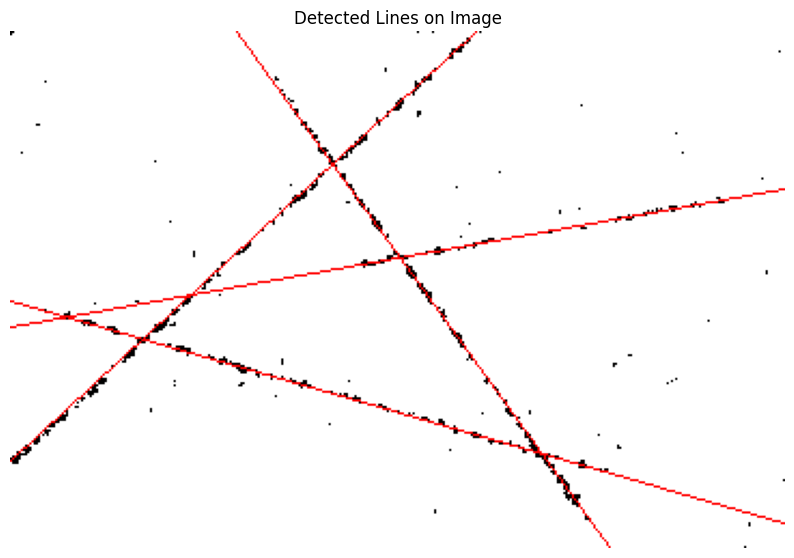

In [243]:
# Draw the lines on the original median-filtered image
img_with_lines = draw_detected_lines(median_filtered, peaks, angle_steps, radius_steps)

# Show the result
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_with_lines, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines on Image")
plt.axis('off')
plt.show()
